# **Facial Recognition by Emiliano Pedraza, Physics Engineer**

This project focuses on building an automated machine learning pipeline to classify human faces using the classic Olivetti Faces dataset from AT&T Laboratories. The goal is to accurately identify the individual subjects from grayscale facial images without applying standard feature scaling.

LIBRARIES

In [1]:
import pandas as pd
from sklearn.datasets import fetch_olivetti_faces
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

OBTAINING THE DATA
Scikit-learn´s *lfw_people* is used to obtain the data, which consists of 400 grayscale images (64 x 64 pixels) of 40 distinct subjects.

In [2]:
from sklearn.datasets import fetch_lfw_people
lfw_people = fetch_lfw_people(color=True)

ACESSING THE DATA AND TRANSFORMING SAMPLE SETS INTO IMAGES


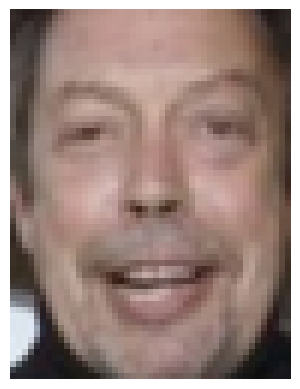

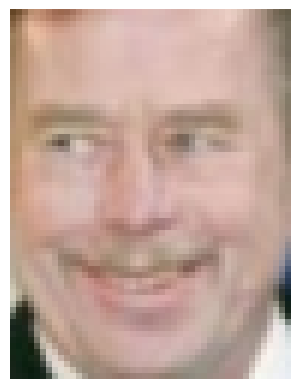

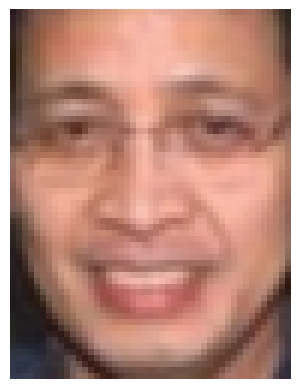

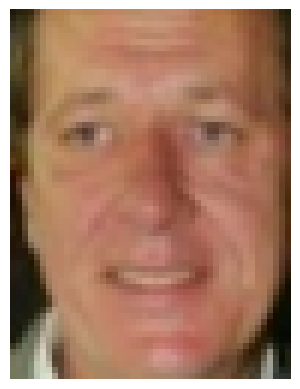

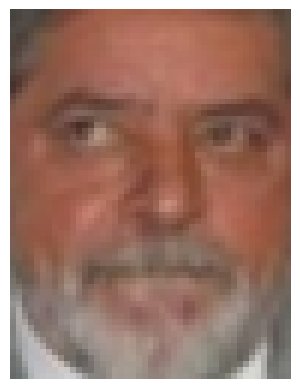

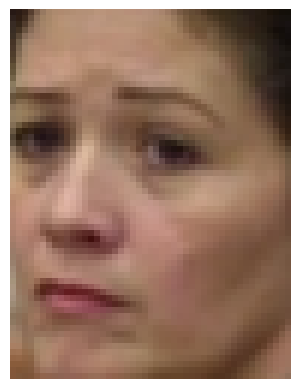

In [5]:
for i in [0, 15, 30, 45, 60, 75]:
  array = np.array(lfw_people.images[i]*250, dtype=np.uint8)
  sample_images = Image.fromarray(array)
  plt.imshow(sample_images)
  plt.axis('off')
  plt.show()

OBTAINING THE DATA, SPLITTING

In [3]:
data=pd.DataFrame(lfw_people.data)

In [4]:
target=pd.DataFrame(lfw_people.target)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=42)

CREATING A PIPELINE AND EXECUTING A GRIDSEARCH PROCESS TO FINE THE BEST PARAMETERS

In [ ]:
pipeline = Pipeline([
    ('model', LogisticRegression())
])

#Parameter grid
param_grid = [
    {
        'model': [LogisticRegression()],
        'model__C': [0.1, 1.0, 10.0]
    },
    {
        'model': [RandomForestClassifier()],
        'model__n_estimators': [100, 200]
    }
]

grid = GridSearchCV(pipeline, param_grid, cv=5)


# Perform GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

#Best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best parameters: {'model': LogisticRegression(), 'model__C': 0.1}
Best cross-validation score: 0.8850874893370463


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CONSTRUCTING THE PIPELINE WITH THE BEST PARAMETERS AND FITTING

In [6]:
pipeline = Pipeline([
    ("model", LogisticRegression(C=0.1))
])

In [ ]:
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test).round(0)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


PREDICTION AND PERFORMANCE

In [ ]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Final Test MAE: {mae:.4f}")
print(f"Final Test R² Score: {r2:.6f}")

SHOWCASE OF FAILING PREDICTIONS

A small sample of faces this model fails to correctly assign to their respective subject are selected and displayed.


In [ ]:
X_test["actual"]=y_test
X_test["predicted"]=predictions

In [ ]:
fails=X_test[X_test["actual"]!=X_test["predicted"]]
fails.shape

(10, 4098)

In [ ]:
fails

,0,1,2,3,4,5,6,7,8,9,...,4088,4089,4090,4091,4092,4093,4094,4095,actual,predicted
395,0.400826,0.495868,0.570248,0.632231,0.648760,0.640496,0.661157,0.636364,0.665289,0.698347,...,0.264463,0.099174,0.181818,0.243802,0.247934,0.161157,0.157025,0.136364,39,29
381,0.355372,0.392562,0.446281,0.462810,0.475207,0.491736,0.500000,0.504132,0.520661,0.545455,...,0.111570,0.140496,0.165289,0.169421,0.173554,0.173554,0.181818,0.185950,38,21
382,0.301653,0.247934,0.177686,0.123967,0.136364,0.198347,0.297521,0.384298,0.442149,0.450413,...,0.351240,0.347107,0.347107,0.334711,0.334711,0.314050,0.305785,0.297521,38,28
39,0.772727,0.764463,0.752066,0.764463,0.785124,0.793388,0.797521,0.809917,0.818182,0.818182,...,0.342975,0.347107,0.347107,0.342975,0.342975,0.342975,0.342975,0.342975,3,14
78,0.223140,0.239669,0.231405,0.198347,0.173554,0.173554,0.173554,0.260331,0.454545,0.582645,...,0.512397,0.458678,0.425620,0.433884,0.466942,0.528926,0.557851,0.566116,7,17
394,0.289256,0.338843,0.417355,0.504132,0.553719,0.561983,0.582645,0.628099,0.669421,0.690083,...,0.500000,0.487603,0.404959,0.359504,0.367769,0.359504,0.351240,0.363636,39,37
5,0.549587,0.545455,0.541322,0.537190,0.537190,0.533058,0.528926,0.533058,0.590909,0.611570,...,0.623967,0.615702,0.661157,0.661157,0.690083,0.714876,0.706612,0.702479,0,20
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0,16
387,0.367769,0.359504,0.380165,0.421488,0.442149,0.446281,0.471074,0.520661,0.537190,0.553719,...,0.272727,0.272727,0.268595,0.264463,0.289256,0.264463,0.276859,0.280992,38,24
386,0.280992,0.314050,0.359504,0.380165,0.392562,0.425620,0.462810,0.500000,0.533058,0.537190,...,0.219008,0.219008,0.219008,0.227273,0.227273,0.223140,0.223140,0.223140,38,24


Looking further into one of these failed predictions, we can view what the original image looks like and who the model mistakenly predicted that image/faced belonged to.

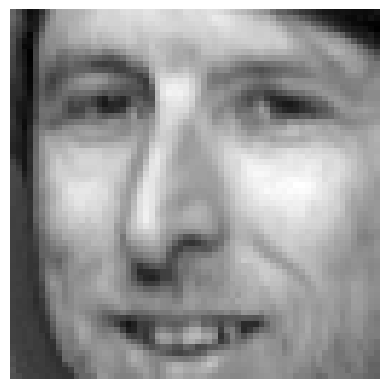

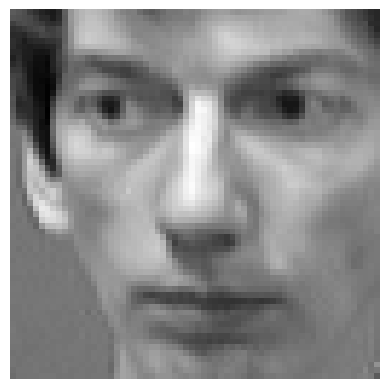

In [ ]:
for i in [382, 282]:
  array = np.array(olivetti_faces.images[i]*250, dtype=np.uint8)
  sample_images = Image.fromarray(array)
  plt.imshow(sample_images, cmap= "grey")
  plt.axis('off')
  plt.show()